In [1]:
#Install libraries
!pip install fairlearn shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 13.8 MB/s eta 0:00:00


In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

import shap
from lime.lime_tabular import LimeTabularExplainer

In [3]:
#Load dataset
adult = fetch_openml("adult", version=2, as_frame=True)

df = adult.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
#Clean and prepare data
df = df.replace("?", np.nan)
df = df.dropna()

df["class"] = df["class"].apply(lambda x: 1 if x == ">50K" else 0)

sensitive_feature = df["sex"]

X = df.drop(columns=["class"])
y = df["class"]

X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States


In [5]:
#Split dataset
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_feature,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
#Build preprocessing and logistic regression model
categorical_features = X.select_dtypes(include=["category", "object"]).columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [7]:
#Model evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.845992260917634

Confusion Matrix:
[[6311  492]
 [ 901 1341]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6803
           1       0.73      0.60      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



In [8]:
#Fairness metrics with Fairlearn
metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test
)

metric_frame.by_group

,accuracy,selection_rate,false_positive_rate,true_positive_rate
sex,,,,
Female,0.917409,0.078136,0.020744,0.482094
Male,0.811980,0.261955,0.103343,0.620543


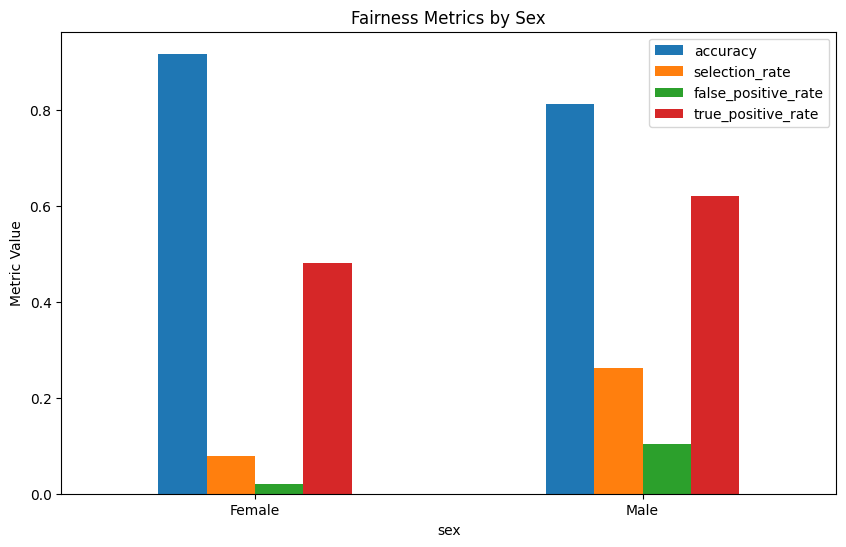

In [9]:
#Visualize fairness metrics
metric_frame.by_group.plot(kind="bar", figsize=(10, 6))
plt.title("Fairness Metrics by Sex")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.show()

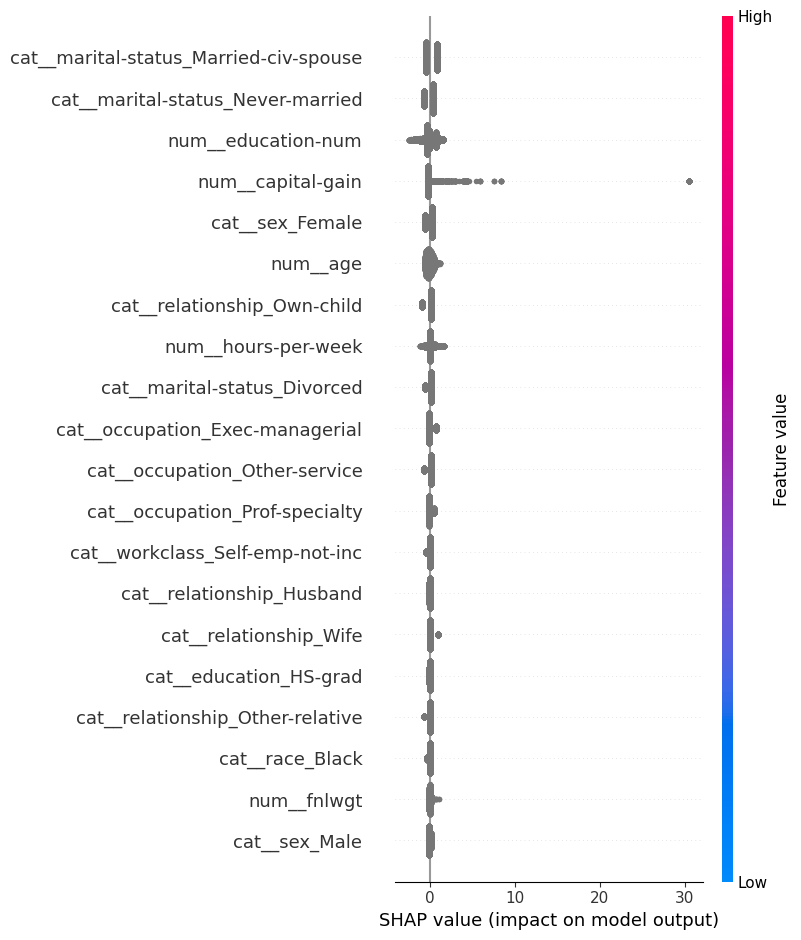

In [10]:
#SHAP global explainability
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.LinearExplainer(
    model.named_steps["classifier"],
    X_train_transformed
)

shap_values = explainer(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

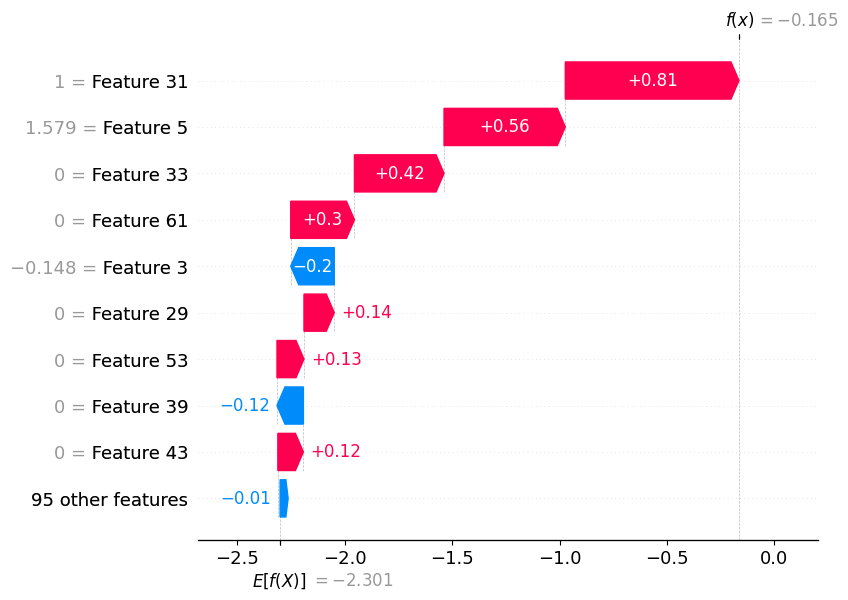

In [11]:
#SHAP local waterfall plot
index = 0

shap.plots.waterfall(shap_values[index], max_display=10)

In [13]:
#LIME local explanation
# Transform data first because LIME needs numeric values
X_train_lime = model.named_steps["preprocessor"].transform(X_train)
X_test_lime = model.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_lime, "toarray"):
    X_train_lime = X_train_lime.toarray()
    X_test_lime = X_test_lime.toarray()

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
class_names = ["<=50K", ">50K"]

# Prediction function for transformed numeric data
def predict_proba_fn(data):
    return model.named_steps["classifier"].predict_proba(data)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification"
)

i = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime[i],
    predict_fn=predict_proba_fn,
    num_features=10
)

lime_exp.show_in_notebook()

# Ethical AI, Fairness, and Explainability Report

## Introduction

Ethical AI focuses on building machine learning systems that are fair, transparent, accountable, and safe. It is important because AI models can affect real people in areas such as hiring, banking, healthcare, and education. If bias exists in the data or model, the system may produce unfair outcomes for certain groups.

## Dataset and Preprocessing

This project uses the Adult Income dataset, a public dataset commonly used for fairness evaluation. The goal is to predict whether a person earns more than $50K per year. The target variable is income class, converted into binary values: 1 for income greater than $50K and 0 otherwise.

The dataset includes features such as age, education, occupation, marital status, hours worked per week, and sex. Missing values were removed. Categorical features were encoded using OneHotEncoder, and numerical features were scaled using StandardScaler. The sensitive attribute selected for fairness analysis was sex.

## Model Training and Evaluation

A logistic regression model was trained using scikit-learn. The dataset was split into training and testing sets using an 80/20 split. Model performance was evaluated using accuracy, confusion matrix, and classification report.

Accuracy gives the overall percentage of correct predictions. The confusion matrix shows true positives, true negatives, false positives, and false negatives. The classification report provides precision, recall, and F1-score.

## Fairness Analysis

Fairlearn was used to evaluate fairness across groups based on the sensitive feature. The metrics used were selection rate, false positive rate, and true positive rate.

Selection rate measures how often the model predicts the positive outcome. False positive rate measures how often the model incorrectly predicts a positive outcome. True positive rate measures how often the model correctly identifies positive cases.

The MetricFrame results allow comparison between male and female groups. Differences in these metrics may indicate possible bias or unequal model behavior across groups.

## Explainability Analysis

SHAP was used for global and local explainability. The SHAP summary plot shows which features had the strongest overall impact on model predictions. Important features may include education, marital status, occupation, age, and hours worked per week.

A SHAP waterfall plot was used to explain one individual prediction. It shows which features increased or decreased the model’s prediction for that person.

LIME was also used to explain individual predictions. LIME identifies the most influential features for a single prediction and helps understand why the model made that decision.

## Ethical Considerations and Recommendations

The model may reflect historical bias in the dataset. For example, income differences between groups may be caused by social and economic inequality, not only individual qualifications. Using sensitive attributes directly or indirectly can lead to unfair predictions.

To improve fairness, future work could compare fairness metrics across more sensitive attributes such as race and age. Bias mitigation techniques from Fairlearn could also be applied. The model should be monitored regularly, and decisions should not rely only on automated predictions.

## Conclusion

This project showed how to train a logistic regression model, evaluate its performance, analyze fairness, and explain predictions using SHAP and LIME. The results demonstrate that ethical AI requires more than accuracy. Fairness, transparency, and accountability are also important when building machine learning systems.

In [14]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 102 (delta 30), reused 76 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 4.03 MiB | 9.06 MiB/s, done.
Resolving deltas: 100% (30/30), done.
